In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train,y_train),(X_test,y_test)=(tf.keras.datasets.mnist.load_data())

In [3]:
X_train=X_train/255.0
X_test=X_test/255.0

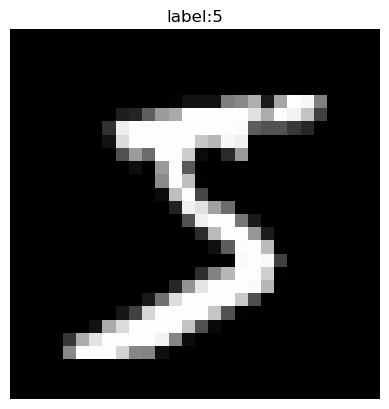

In [4]:
#display one image

plt.imshow(X_train[0],cmap='gray')
plt.title(f'label:{y_train[0]}')
plt.axis('off')
plt.show()

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Flatten,Dense

In [6]:
model=Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history=model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9203 - loss: 0.2791 - val_accuracy: 0.9640 - val_loss: 0.1315
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9650 - loss: 0.1212 - val_accuracy: 0.9725 - val_loss: 0.0954
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9756 - loss: 0.0828 - val_accuracy: 0.9778 - val_loss: 0.0845
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9811 - loss: 0.0614 - val_accuracy: 0.9785 - val_loss: 0.0748
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9861 - loss: 0.0474 - val_accuracy: 0.9753 - val_loss: 0.0837
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9885 - loss: 0.0373 - val_accuracy: 0.9785 - val_loss: 0.0763
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9907 - loss: 0.0300 - val_accuracy: 0.9798 - val_loss: 0.0807
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9926 - loss

In [10]:
test_loss,test_accuracy=model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9776 - loss: 0.0824


In [11]:
test_loss

0.08236896991729736

In [12]:
test_accuracy*100,'%'

(97.75999784469604, '%')

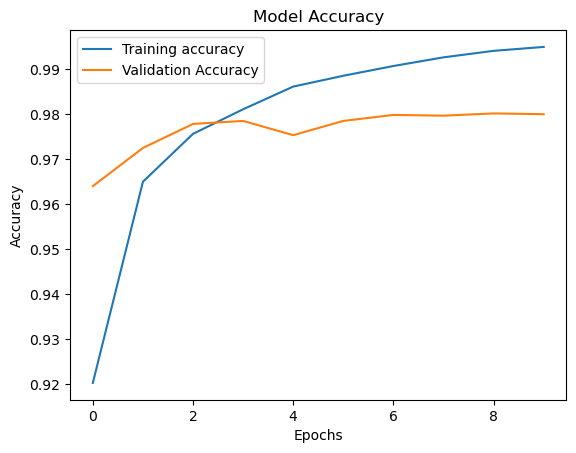

In [13]:
plt.plot(history.history['accuracy'],label='Training accuracy'),
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

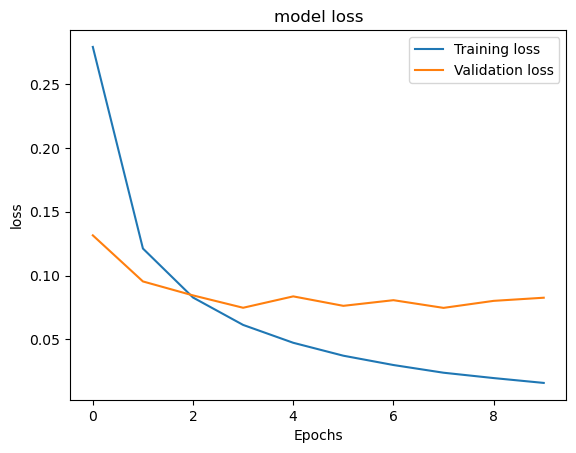

In [14]:
plt.plot(history.history['loss'],label='Training loss')
plt.plot(history.history['val_loss'],label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.title('model loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
Actual: 7
Predicted: 7


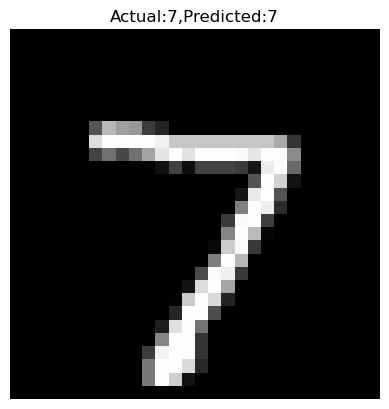

Actual: 2
Predicted: 2


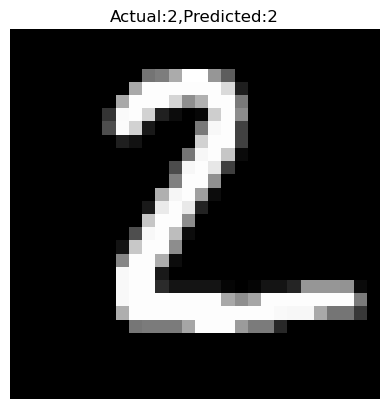

Actual: 1
Predicted: 1


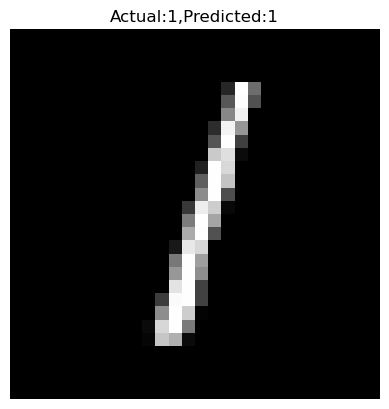

Actual: 0
Predicted: 0


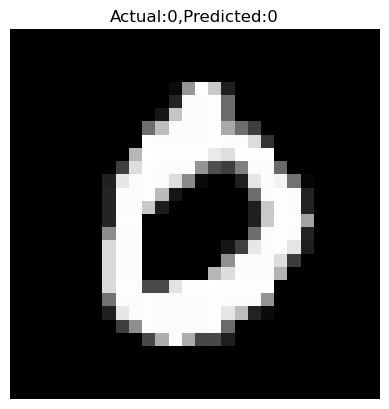

Actual: 4
Predicted: 4


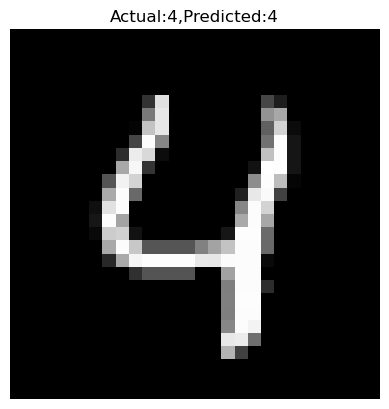

In [15]:
predictions=model.predict(X_test[:5])

for i in range(5):
    predicted_digit=np.argmax(predictions[i])
    print('Actual:',y_test[i])
    print('Predicted:',predicted_digit)

    plt.imshow(X_test[i],cmap='gray')
    plt.title(f"Actual:{y_test[i]},Predicted:{predicted_digit}")
    plt.axis('off')
    plt.show()

In [16]:
import os

os.makedirs("models", exist_ok=True)

model.save("models/mnist_model.keras")

print("Model saved successfully!")

Model saved successfully!
